# 02 - EDA & Featurization

**Purpose:** Load the filtered intermetallics dataset, engineer MAGPIE composition descriptors, a one-hot encoded crystal system, and valence electron concentration (VEC), then explore the target distribution and its relationship to VEC.

**Input:** `../data/bradley_intermetallics_elasticity.csv`

**Outputs:** `../data/bradley_intermetallics_featured.csv`, `../figures/bulk_modulus_distribution.png`, `../figures/vec_vs_bulk_modulus.png`

## Feature engineering: MAGPIE descriptors, crystal system, and VEC

In [1]:
import ast
import numpy as np
import pandas as pd
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

intermetallics_df = pd.read_csv("../data/bradley_intermetallics_elasticity.csv")
intermetallics_df["elements"] = intermetallics_df["elements"].apply(ast.literal_eval)

# Build pymatgen Composition objects assuming equal-atom stoichiometry: the MP elasticity
# endpoint used in 01_data_acquisition does not expose exact site occupancies, only the element list
intermetallics_df["composition"] = intermetallics_df["elements"].apply(lambda els: Composition(" ".join(els)))

# Valence electron concentration (Guo & Liu group-based convention used for alloy/intermetallic descriptors)
VEC_TABLE = {
    "Sc": 3, "Ti": 4, "V": 5, "Cr": 6, "Mn": 7, "Fe": 8, "Co": 9, "Ni": 10, "Cu": 11, "Zn": 12,
    "Y": 3, "Zr": 4, "Nb": 5, "Mo": 6, "Tc": 7, "Ru": 8, "Rh": 9, "Pd": 10, "Ag": 11, "Cd": 12,
    "La": 3, "Hf": 4, "Ta": 5, "W": 6, "Re": 7, "Os": 8, "Ir": 9, "Pt": 10, "Au": 11, "Hg": 12,
    "Li": 1, "Na": 1, "K": 1, "Rb": 1, "Cs": 1,
    "Be": 2, "Mg": 2, "Ca": 2, "Sr": 2, "Ba": 2,
    "Al": 3, "Ga": 3, "In": 3, "Tl": 3,
    "Si": 4, "Ge": 4, "Sn": 4, "Pb": 4,
    "Sb": 5, "Bi": 5,
    "B": 3,
}

def compute_valence_electron_concentration(composition):
    total_atoms = composition.num_atoms
    weighted_vec = sum(VEC_TABLE.get(el.symbol, 0) * amount for el, amount in composition.items())
    return weighted_vec / total_atoms

intermetallics_df["VEC"] = intermetallics_df["composition"].apply(compute_valence_electron_concentration)

# Chemical-system group key for GroupKFold in later notebooks (sorted elements joined by a hyphen,
# e.g. "Co-Fe"). Grouping by this key prevents the model from seeing the same chemical system in
# both train and test folds.
intermetallics_df["chem_system"] = intermetallics_df["elements"].apply(lambda els: "-".join(sorted(els)))

# MAGPIE composition-based descriptors (132 features)
magpie_featurizer = ElementProperty.from_preset("magpie")
magpie_features_df = magpie_featurizer.featurize_dataframe(intermetallics_df, col_id="composition", ignore_errors=True)
magpie_feature_names = magpie_featurizer.feature_labels()

# One-hot encode crystal system so it can be used as a model input
crystal_system_dummies = pd.get_dummies(magpie_features_df["crystal_system"], prefix="cs")

featured_df = pd.concat([magpie_features_df.drop(columns=["composition"]), crystal_system_dummies], axis=1)
featured_df.to_csv("../data/bradley_intermetallics_featured.csv", index=False)

print(f"Featured dataset shape: {featured_df.shape}")
print(f"MAGPIE features: {len(magpie_feature_names)}, crystal-system dummies: {crystal_system_dummies.shape[1]}, plus VEC and chem_system group key")
featured_df.head()

ElementProperty:   0%|          | 0/5242 [00:00<?, ?it/s]

Featured dataset shape: (5242, 147)
MAGPIE features: 132, crystal-system dummies: 7, plus VEC and chem_system group key


,material_id,formula,bulk_modulus_vrh,crystal_system,elements,num_elements,VEC,chem_system,MagpieData minimum Number,MagpieData maximum Number,...,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,cs_cubic,cs_hex_,cs_mono,cs_ortho,cs_tet,cs_tri,cs_trig
0,mp-171,VNi3,217.129,tet,"[Ni, V]",2,7.5,Ni-V,23.0,28.0,...,227.0,2.0,225.0,False,False,False,False,True,False,False
1,mp-173,MnAl6,110.784,ortho,"[Al, Mn]",2,5.0,Al-Mn,13.0,25.0,...,221.0,4.0,217.0,False,False,False,True,False,False,False
2,mp-179,YZn,52.307,cubic,"[Y, Zn]",2,7.5,Y-Zn,30.0,39.0,...,194.0,0.0,194.0,True,False,False,False,False,False,False
3,mp-188,AlPt3,224.023,cubic,"[Al, Pt]",2,6.5,Al-Pt,13.0,78.0,...,225.0,0.0,225.0,True,False,False,False,False,False,False
4,mp-189,SiRu,203.638,cubic,"[Ru, Si]",2,6.0,Ru-Si,14.0,44.0,...,210.5,16.5,194.0,True,False,False,False,False,False,False


## Exploratory Data Analysis

### Bulk modulus distribution

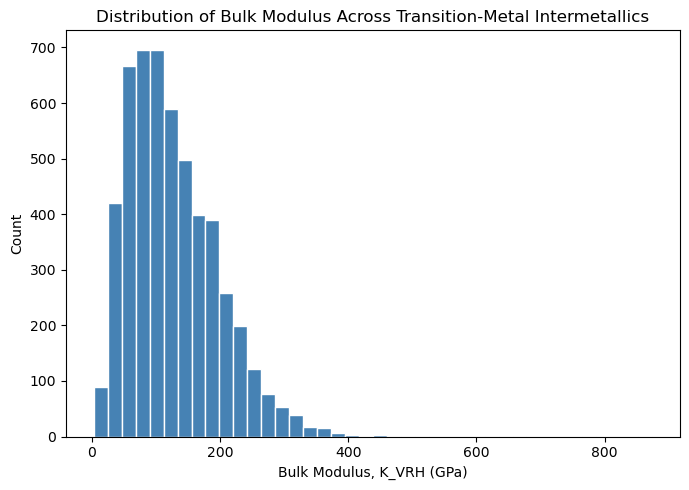

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(featured_df["bulk_modulus_vrh"], bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Bulk Modulus, K_VRH (GPa)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Bulk Modulus Across Transition-Metal Intermetallics")
fig.tight_layout()
fig.savefig("../figures/bulk_modulus_distribution.png", dpi=200)
plt.show()

### VEC vs. bulk modulus

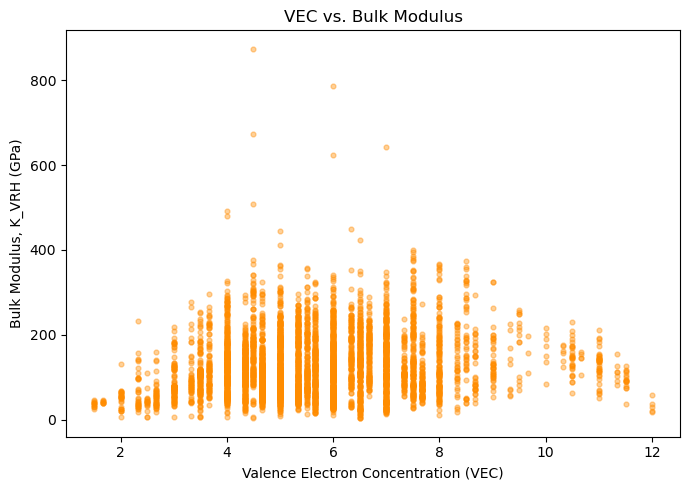

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(featured_df["VEC"], featured_df["bulk_modulus_vrh"], s=12, alpha=0.4, color="darkorange")
ax.set_xlabel("Valence Electron Concentration (VEC)")
ax.set_ylabel("Bulk Modulus, K_VRH (GPa)")
ax.set_title("VEC vs. Bulk Modulus")
fig.tight_layout()
fig.savefig("../figures/vec_vs_bulk_modulus.png", dpi=200)
plt.show()